# Fund Performance Analytics

## Objective

Analyze the performance and risk of mutual fund schemes using financial metrics such as Daily Returns, CAGR, Sharpe Ratio, Sortino Ratio, Alpha, Beta, Maximum Drawdown, and Benchmark Comparison.

In [28]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy.stats import linregress

plt.style.use("default")

## 1. Load Datasets

Load the processed datasets required for fund performance analysis.

In [29]:
nav = pd.read_csv("../data/processed/02_nav_history.csv")

fund_master = pd.read_csv("../data/processed/01_fund_master.csv")

performance = pd.read_csv("../data/processed/07_scheme_performance.csv")

benchmark = pd.read_csv("../data/processed/10_benchmark_indices.csv")

In [30]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [31]:
fund_master.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [32]:
performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [33]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [38]:
nav["date"] = pd.to_datetime(nav["date"])

benchmark["date"] = pd.to_datetime(benchmark["date"])

In [39]:
nav.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[ns]
 2   nav        46000 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 1.1 MB


In [40]:
benchmark.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8050 entries, 0 to 8049
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         8050 non-null   datetime64[ns]
 1   index_name   8050 non-null   object        
 2   close_value  8050 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 188.8+ KB


In [41]:
nav["amfi_code"].nunique()

40

In [42]:
fund_master["amfi_code"].nunique()

40

In [43]:
set(nav["amfi_code"]) - set(fund_master["amfi_code"])

set()

# 2. Daily Returns

## Objective

Calculate the daily percentage return of each mutual fund using historical NAV values.

## Business Question

How much does each mutual fund gain or lose on a daily basis?

In [44]:
# Calculate Daily Returns

nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

# Preview
nav.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


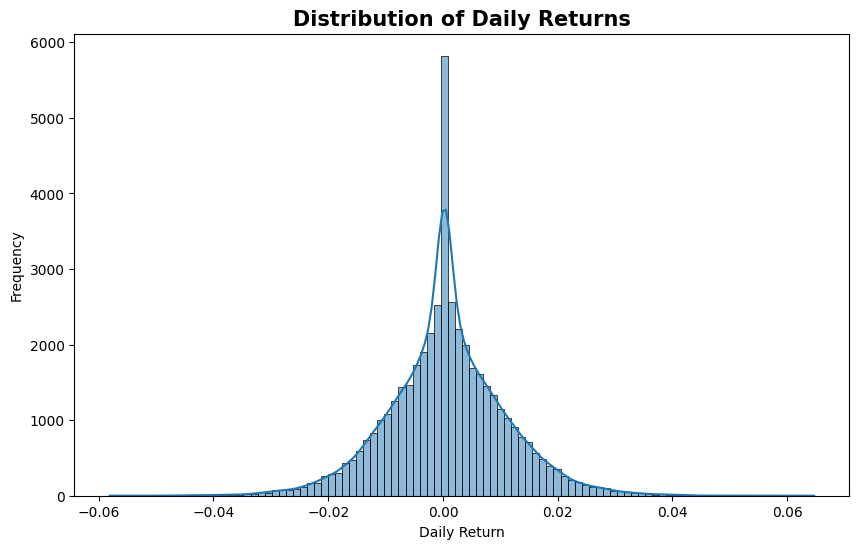

In [45]:
print(nav["daily_return"].describe())

plt.figure(figsize=(10,6))

sns.histplot(
    nav["daily_return"],
    bins=100,
    kde=True
)

plt.title(
    "Distribution of Daily Returns",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

### Business Insight

- Most daily returns are concentrated around zero, indicating relatively small day-to-day NAV changes.
- Positive and negative returns are balanced, reflecting normal market behavior.
- Extreme daily returns are rare and correspond to periods of higher market volatility.

# 3. Compound Annual Growth Rate (CAGR)

## Objective

Calculate the annualized growth rate of mutual funds over different investment horizons.

## Business Question

Which mutual funds delivered the highest annualized returns over 1-year, 3-year, and the available historical period?

In [51]:
# Merge NAV with Scheme Names

cagr_df = nav.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code"
)

cagr_df.head()

,amfi_code,date,nav,daily_return,scheme_name
0,100016,2022-01-03,520.4608,NaN,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,-0.010306,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,0.012865,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,-0.011377,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,-0.001210,HDFC Top 100 Fund - Regular Plan - Growth


In [52]:
latest_date = cagr_df["date"].max()

results = []

for code, group in cagr_df.groupby("amfi_code"):

    group = group.sort_values("date")

    scheme = group["scheme_name"].iloc[0]

    latest_nav = group.iloc[-1]["nav"]

    # ---------------- 1 Year ----------------

    one_year = latest_date - pd.DateOffset(years=1)

    temp = group[group["date"] >= one_year]

    cagr1 = np.nan

    if len(temp) > 1:

        start_nav = temp.iloc[0]["nav"]

        cagr1 = ((latest_nav/start_nav)**1 - 1) * 100

    # ---------------- 3 Year ----------------

    three_year = latest_date - pd.DateOffset(years=3)

    temp = group[group["date"] >= three_year]

    cagr3 = np.nan

    if len(temp) > 1:

        start_nav = temp.iloc[0]["nav"]

        cagr3 = ((latest_nav/start_nav)**(1/3) - 1) * 100

    # ---------------- Since Inception ----------------

    years = (
        (group["date"].max() - group["date"].min()).days
        /365.25
    )

    start_nav = group.iloc[0]["nav"]

    cagr_since = (
        ((latest_nav/start_nav)**(1/years)-1)
        *100
    )

    results.append([
        code,
        scheme,
        cagr1,
        cagr3,
        cagr_since
    ])

In [53]:
cagr_table = pd.DataFrame(
    results,
    columns=[
        "AMFI Code",
        "Scheme Name",
        "1 Year CAGR (%)",
        "3 Year CAGR (%)",
        "Since Inception CAGR (%)"
    ]
)

# Round values

cagr_table.iloc[:,2:] = (
    cagr_table.iloc[:,2:]
    .round(2)
)

cagr_table.head()

,AMFI Code,Scheme Name,1 Year CAGR (%),3 Year CAGR (%),Since Inception CAGR (%)
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-2.22,1.29,2.64
1,100025,HDFC Short Term Debt Fund - Regular - Growth,3.70,3.92,4.46
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.23,32.44,30.12
3,101206,ABSL Frontline Equity Fund - Regular - Growth,47.92,28.97,23.54
4,101207,ABSL Small Cap Fund - Regular - Growth,-23.99,-4.15,7.94


In [56]:
cagr_table["Rank"] = (
    cagr_table["3 Year CAGR (%)"]
    .rank(
        ascending=False,
        method="dense"
    )
)

cagr_table = (
    cagr_table
    .sort_values("Rank")
    .reset_index(drop=True)
)

cagr_table.style\
.background_gradient(
    subset=["3 Year CAGR (%)"],
    cmap="Greens"
)\
.background_gradient(
    subset=["1 Year CAGR (%)"],
    cmap="Blues"
)\
.background_gradient(
    subset=["Since Inception CAGR (%)"],
    cmap="Purples"
)

,AMFI Code,Scheme Name,1 Year CAGR (%),3 Year CAGR (%),Since Inception CAGR (%),Rank
0,119094,Axis Midcap Fund - Regular - Growth,22.260000,35.110000,28.210000,1.000000
1,148567,Mirae Asset Large Cap Fund - Regular - Growth,20.360000,34.000000,30.970000,2.000000
2,120504,ICICI Pru Bluechip Fund - Direct - Growth,13.060000,32.490000,23.300000,3.000000
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Growth,53.230000,32.440000,30.120000,4.000000
4,120505,ICICI Pru Midcap Fund - Regular - Growth,29.600000,31.780000,32.830000,5.000000
5,119551,SBI Bluechip Fund - Regular Plan - Growth,60.440000,30.460000,25.800000,6.000000
6,120843,Kotak Flexicap Fund - Regular - Growth,26.660000,29.580000,30.910000,7.000000
7,148569,Mirae Asset Tax Saver Fund - Regular - Growth,39.750000,29.180000,31.950000,8.000000
8,101206,ABSL Frontline Equity Fund - Regular - Growth,47.920000,28.970000,23.540000,9.000000
9,149324,DSP Small Cap Fund - Regular - Growth,65.140000,27.000000,32.290000,10.000000


In [57]:
cagr_table.to_csv(
    "../reports/cagr_table.csv",
    index=False
)

print("CAGR Table Saved Successfully!")

CAGR Table Saved Successfully!


### Business Insight

- CAGR measures the annualized growth rate of mutual funds over a specific investment horizon.
- Higher 3-year CAGR indicates stronger long-term performance.
- Since the dataset contains approximately 4.4 years of NAV history, the available historical CAGR is reported as "Since Inception CAGR".
- This comparison table helps identify consistently high-performing mutual fund schemes.

# 4. Sharpe Ratio

## Objective

Measure the risk-adjusted performance of each mutual fund.

## Business Question

Which mutual funds generated the highest return for the level of risk they took?

In [58]:
risk_free_rate = 0.065

In [59]:
sharpe_results = []

for code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) == 0:
        continue

    annual_return = returns.mean() * 252

    annual_volatility = returns.std() * np.sqrt(252)

    sharpe = (
        (annual_return - risk_free_rate)
        / annual_volatility
    )

    sharpe_results.append([
        code,
        annual_return * 100,
        annual_volatility * 100,
        sharpe
    ])

In [60]:
sharpe_table = pd.DataFrame(
    sharpe_results,
    columns=[
        "AMFI Code",
        "Annual Return (%)",
        "Annual Volatility (%)",
        "Sharpe Ratio"
    ]
)

sharpe_table = sharpe_table.merge(
    fund_master[
        ["amfi_code","scheme_name"]
    ],
    left_on="AMFI Code",
    right_on="amfi_code"
)

sharpe_table.drop(
    columns="amfi_code",
    inplace=True
)

sharpe_table.head()

,AMFI Code,Annual Return (%),Annual Volatility (%),Sharpe Ratio,scheme_name
0,100016,3.568303,14.548135,-0.201517,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,4.285356,3.905246,-0.567095,HDFC Short Term Debt Fund - Regular - Growth
2,100033,27.211057,18.936711,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,21.464662,14.568213,1.027213,ABSL Frontline Equity Fund - Regular - Growth
4,101207,10.696212,25.797322,0.162661,ABSL Small Cap Fund - Regular - Growth


In [62]:
sharpe_table[
    [
        "Annual Return (%)",
        "Annual Volatility (%)",
        "Sharpe Ratio"
    ]
] = (
    sharpe_table[
        [
            "Annual Return (%)",
            "Annual Volatility (%)",
            "Sharpe Ratio"
        ]
    ].round(3)
)

sharpe_table["Rank"] = (
    sharpe_table["Sharpe Ratio"]
    .rank(
        ascending=False,
        method="dense"
    )
)

sharpe_table = (
    sharpe_table
    .sort_values("Rank")
    .reset_index(drop=True)
)

sharpe_table.head(10)

,AMFI Code,Annual Return (%),Annual Volatility (%),Sharpe Ratio,scheme_name,Rank
0,148567,27.057,14.194,1.448,Mirae Asset Large Cap Fund - Regular - Growth,1.0
1,120843,27.260,15.887,1.307,Kotak Flexicap Fund - Regular - Growth,2.0
2,148569,28.326,17.674,1.235,Mirae Asset Tax Saver Fund - Regular - Growth,3.0
3,119551,23.103,13.741,1.208,SBI Bluechip Fund - Regular Plan - Growth,4.0
4,120505,29.265,19.291,1.180,ICICI Pru Midcap Fund - Regular - Growth,5.0
5,149323,26.591,17.746,1.132,DSP Midcap Fund - Regular - Growth,6.0
6,100033,27.211,18.937,1.094,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,7.0
7,118632,21.804,14.148,1.082,Nippon India Large Cap Fund - Regular - Growth,8.0
8,101206,21.465,14.568,1.027,ABSL Frontline Equity Fund - Regular - Growth,9.0
9,120504,21.245,14.364,1.027,ICICI Pru Bluechip Fund - Direct - Growth,9.0


In [63]:
sharpe_table.style.background_gradient(
    subset=["Sharpe Ratio"],
    cmap="Greens"
)

,AMFI Code,Annual Return (%),Annual Volatility (%),Sharpe Ratio,scheme_name,Rank
0,148567,27.057000,14.194000,1.448000,Mirae Asset Large Cap Fund - Regular - Growth,1.000000
1,120843,27.260000,15.887000,1.307000,Kotak Flexicap Fund - Regular - Growth,2.000000
2,148569,28.326000,17.674000,1.235000,Mirae Asset Tax Saver Fund - Regular - Growth,3.000000
3,119551,23.103000,13.741000,1.208000,SBI Bluechip Fund - Regular Plan - Growth,4.000000
4,120505,29.265000,19.291000,1.180000,ICICI Pru Midcap Fund - Regular - Growth,5.000000
5,149323,26.591000,17.746000,1.132000,DSP Midcap Fund - Regular - Growth,6.000000
6,100033,27.211000,18.937000,1.094000,HDFC Mid-Cap Opportunities Fund - Regular - Growth,7.000000
7,118632,21.804000,14.148000,1.082000,Nippon India Large Cap Fund - Regular - Growth,8.000000
8,101206,21.465000,14.568000,1.027000,ABSL Frontline Equity Fund - Regular - Growth,9.000000
9,120504,21.245000,14.364000,1.027000,ICICI Pru Bluechip Fund - Direct - Growth,9.000000


In [64]:
sharpe_table.to_csv(
    "../reports/sharpe_ratio.csv",
    index=False
)

print("Sharpe Ratio Saved Successfully!")

Sharpe Ratio Saved Successfully!


### Business Insight

- The Sharpe Ratio evaluates the return generated per unit of risk.
- Funds with higher Sharpe Ratios provide superior risk-adjusted performance.
- Investors generally prefer funds with consistently higher Sharpe Ratios, as they indicate better compensation for the level of volatility assumed.

# 5. Sortino Ratio

## Objective

Evaluate the downside risk-adjusted performance of mutual funds.

## Business Question

Which mutual funds generated higher returns while minimizing downside risk?

In [65]:
risk_free_rate = 0.065

sortino_results = []

for code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) == 0:
        continue

    # Annual Return
    annual_return = returns.mean() * 252

    # Downside Returns Only
    downside = returns[returns < 0]

    if len(downside) == 0:
        continue

    downside_std = downside.std() * np.sqrt(252)

    sortino = (
        (annual_return - risk_free_rate)
        / downside_std
    )

    sortino_results.append([
        code,
        annual_return * 100,
        downside_std * 100,
        sortino
    ])

In [66]:
sortino_table = pd.DataFrame(
    sortino_results,
    columns=[
        "AMFI Code",
        "Annual Return (%)",
        "Downside Risk (%)",
        "Sortino Ratio"
    ]
)

sortino_table = sortino_table.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    left_on="AMFI Code",
    right_on="amfi_code"
)

sortino_table.drop(
    columns="amfi_code",
    inplace=True
)

sortino_table.head()

,AMFI Code,Annual Return (%),Downside Risk (%),Sortino Ratio,scheme_name
0,100016,3.568303,8.351285,-0.351047,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,4.285356,2.351449,-0.941821,HDFC Short Term Debt Fund - Regular - Growth
2,100033,27.211057,11.322876,1.829134,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,21.464662,8.315721,1.799563,ABSL Frontline Equity Fund - Regular - Growth
4,101207,10.696212,15.168286,0.276644,ABSL Small Cap Fund - Regular - Growth


In [67]:
sortino_table[
    [
        "Annual Return (%)",
        "Downside Risk (%)",
        "Sortino Ratio"
    ]
] = (
    sortino_table[
        [
            "Annual Return (%)",
            "Downside Risk (%)",
            "Sortino Ratio"
        ]
    ].round(3)
)

sortino_table["Rank"] = (
    sortino_table["Sortino Ratio"]
    .rank(
        ascending=False,
        method="dense"
    )
)

sortino_table = (
    sortino_table
    .sort_values("Rank")
    .reset_index(drop=True)
)

sortino_table.head(10)

,AMFI Code,Annual Return (%),Downside Risk (%),Sortino Ratio,scheme_name,Rank
0,148567,27.057,8.617,2.386,Mirae Asset Large Cap Fund - Regular - Growth,1.0
1,120843,27.260,8.781,2.364,Kotak Flexicap Fund - Regular - Growth,2.0
2,148569,28.326,10.166,2.147,Mirae Asset Tax Saver Fund - Regular - Growth,3.0
3,119551,23.103,7.758,2.140,SBI Bluechip Fund - Regular Plan - Growth,4.0
4,120505,29.265,11.218,2.029,ICICI Pru Midcap Fund - Regular - Growth,5.0
5,149323,26.591,10.715,1.875,DSP Midcap Fund - Regular - Growth,6.0
6,118632,21.804,8.272,1.850,Nippon India Large Cap Fund - Regular - Growth,7.0
7,100033,27.211,11.323,1.829,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,8.0
8,120504,21.245,8.168,1.805,ICICI Pru Bluechip Fund - Direct - Growth,9.0
9,101206,21.465,8.316,1.800,ABSL Frontline Equity Fund - Regular - Growth,10.0


In [68]:
sortino_table.style.background_gradient(
    subset=["Sortino Ratio"],
    cmap="Greens"
)

,AMFI Code,Annual Return (%),Downside Risk (%),Sortino Ratio,scheme_name,Rank
0,148567,27.057000,8.617000,2.386000,Mirae Asset Large Cap Fund - Regular - Growth,1.000000
1,120843,27.260000,8.781000,2.364000,Kotak Flexicap Fund - Regular - Growth,2.000000
2,148569,28.326000,10.166000,2.147000,Mirae Asset Tax Saver Fund - Regular - Growth,3.000000
3,119551,23.103000,7.758000,2.140000,SBI Bluechip Fund - Regular Plan - Growth,4.000000
4,120505,29.265000,11.218000,2.029000,ICICI Pru Midcap Fund - Regular - Growth,5.000000
5,149323,26.591000,10.715000,1.875000,DSP Midcap Fund - Regular - Growth,6.000000
6,118632,21.804000,8.272000,1.850000,Nippon India Large Cap Fund - Regular - Growth,7.000000
7,100033,27.211000,11.323000,1.829000,HDFC Mid-Cap Opportunities Fund - Regular - Growth,8.000000
8,120504,21.245000,8.168000,1.805000,ICICI Pru Bluechip Fund - Direct - Growth,9.000000
9,101206,21.465000,8.316000,1.800000,ABSL Frontline Equity Fund - Regular - Growth,10.000000


In [69]:
sortino_table.to_csv(
    "../reports/sortino_ratio.csv",
    index=False
)

print("Sortino Ratio Saved Successfully!")

Sortino Ratio Saved Successfully!


### Business Insight

- The Sortino Ratio measures return relative to downside risk only.
- Funds with higher Sortino Ratios have delivered stronger returns while limiting losses during negative market movements.
- Compared to the Sharpe Ratio, the Sortino Ratio provides a more investor-focused measure of performance because it ignores positive volatility.

# 6. Alpha and Beta Analysis

## Objective

Evaluate the relationship between mutual fund returns and the NIFTY 100 benchmark using linear regression.

## Business Question

How much excess return (Alpha) does each fund generate, and how sensitive is it (Beta) to market movements?

In [70]:
benchmark.head(10)

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15
5,2022-01-10,NIFTY50,18124.84
6,2022-01-11,NIFTY50,18256.96
7,2022-01-12,NIFTY50,18162.54
8,2022-01-13,NIFTY50,18179.05
9,2022-01-14,NIFTY50,17971.75


In [71]:
benchmark["index_name"].unique()

array(['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP',
       'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT'], dtype=object)

In [72]:
# Keep only NIFTY100

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

# Sort

nifty100 = nifty100.sort_values("date")

# Daily Returns

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [73]:
alpha_beta_results = []

for code, group in nav.groupby("amfi_code"):

    temp = group.merge(
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    )

    temp = temp.dropna()

    if len(temp) < 30:
        continue

    beta, intercept, r_value, p_value, std_err = linregress(
        temp["benchmark_return"],
        temp["daily_return"]
    )

    alpha = intercept * 252

    alpha_beta_results.append([
        code,
        alpha * 100,
        beta,
        r_value**2
    ])

In [74]:
alpha_beta = pd.DataFrame(
    alpha_beta_results,
    columns=[
        "AMFI Code",
        "Alpha (%)",
        "Beta",
        "R²"
    ]
)

alpha_beta = alpha_beta.merge(
    fund_master[
        ["amfi_code","scheme_name"]
    ],
    left_on="AMFI Code",
    right_on="amfi_code"
)

alpha_beta.drop(
    columns="amfi_code",
    inplace=True
)

alpha_beta.head()

,AMFI Code,Alpha (%),Beta,R²,scheme_name
0,100016,3.747581,-0.058268,0.002665,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,4.281792,0.001158,0.000015,HDFC Short Term Debt Fund - Regular - Growth
2,100033,27.195355,0.005104,0.000012,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,21.399785,0.021086,0.000348,ABSL Frontline Equity Fund - Regular - Growth
4,101207,10.897092,-0.065289,0.001064,ABSL Small Cap Fund - Regular - Growth


In [78]:
alpha_beta.shape

(40, 6)

In [79]:
alpha_beta[
    ["Alpha (%)","Beta","R²"]
] = alpha_beta[
    ["Alpha (%)","Beta","R²"]
].round(3)

alpha_beta["Alpha Rank"] = (
    alpha_beta["Alpha (%)"]
    .rank(
        ascending=False,
        method="dense"
    )
)

alpha_beta = (
    alpha_beta
    .sort_values("Alpha Rank")
    .reset_index(drop=True)
)

alpha_beta.head(10)

,AMFI Code,Alpha (%),Beta,R²,scheme_name,Alpha Rank
0,119598,30.337,-0.023,0.000,SBI Small Cap Fund - Regular Plan - Growth,1.0
1,149324,30.058,0.011,0.000,DSP Small Cap Fund - Regular - Growth,2.0
2,120505,29.264,0.001,0.000,ICICI Pru Midcap Fund - Regular - Growth,3.0
3,148569,28.270,0.018,0.000,Mirae Asset Tax Saver Fund - Regular - Growth,4.0
4,120843,27.330,-0.023,0.000,Kotak Flexicap Fund - Regular - Growth,5.0
5,100033,27.195,0.005,0.000,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,6.0
6,148567,26.984,0.024,0.000,Mirae Asset Large Cap Fund - Regular - Growth,7.0
7,149323,26.599,-0.003,0.000,DSP Midcap Fund - Regular - Growth,8.0
8,119094,26.077,-0.066,0.002,Axis Midcap Fund - Regular - Growth,9.0
9,119551,23.201,-0.032,0.001,SBI Bluechip Fund - Regular Plan - Growth,10.0


In [80]:
alpha_beta.style.background_gradient(
    subset=["Alpha (%)"],
    cmap="Greens"
)

,AMFI Code,Alpha (%),Beta,R²,scheme_name,Alpha Rank
0,119598,30.337000,-0.023000,0.000000,SBI Small Cap Fund - Regular Plan - Growth,1.000000
1,149324,30.058000,0.011000,0.000000,DSP Small Cap Fund - Regular - Growth,2.000000
2,120505,29.264000,0.001000,0.000000,ICICI Pru Midcap Fund - Regular - Growth,3.000000
3,148569,28.270000,0.018000,0.000000,Mirae Asset Tax Saver Fund - Regular - Growth,4.000000
4,120843,27.330000,-0.023000,0.000000,Kotak Flexicap Fund - Regular - Growth,5.000000
5,100033,27.195000,0.005000,0.000000,HDFC Mid-Cap Opportunities Fund - Regular - Growth,6.000000
6,148567,26.984000,0.024000,0.000000,Mirae Asset Large Cap Fund - Regular - Growth,7.000000
7,149323,26.599000,-0.003000,0.000000,DSP Midcap Fund - Regular - Growth,8.000000
8,119094,26.077000,-0.066000,0.002000,Axis Midcap Fund - Regular - Growth,9.000000
9,119551,23.201000,-0.032000,0.001000,SBI Bluechip Fund - Regular Plan - Growth,10.000000


In [81]:
alpha_beta.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

print("Alpha & Beta CSV Saved Successfully!")

Alpha & Beta CSV Saved Successfully!


### Business Insight

- Alpha measures the excess return generated by a mutual fund compared to the NIFTY 100 benchmark.
- Beta indicates how sensitive a fund is to market movements.
- A positive Alpha suggests the fund outperformed the benchmark after accounting for market risk.
- Funds with Beta greater than 1 are more volatile than the benchmark, while Beta less than 1 indicates lower market sensitivity.

# 7. Maximum Drawdown

## Objective

Measure the maximum loss experienced by each mutual fund from its historical peak NAV.

## Business Question

Which mutual funds experienced the smallest and largest declines from their peak value?

In [82]:
drawdown_results = []

for code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date").copy()

    # Running maximum NAV
    group["running_max"] = group["nav"].cummax()

    # Drawdown
    group["drawdown"] = (
        group["nav"] /
        group["running_max"]
    ) - 1

    max_dd = group["drawdown"].min()

    dd_date = group.loc[
        group["drawdown"].idxmin(),
        "date"
    ]

    drawdown_results.append([
        code,
        max_dd * 100,
        dd_date
    ])

In [83]:
drawdown_table = pd.DataFrame(
    drawdown_results,
    columns=[
        "AMFI Code",
        "Maximum Drawdown (%)",
        "Worst Drawdown Date"
    ]
)

drawdown_table = drawdown_table.merge(
    fund_master[
        ["amfi_code","scheme_name"]
    ],
    left_on="AMFI Code",
    right_on="amfi_code"
)

drawdown_table.drop(
    columns="amfi_code",
    inplace=True
)

drawdown_table.head()

,AMFI Code,Maximum Drawdown (%),Worst Drawdown Date,scheme_name
0,100016,-24.734441,2022-09-15,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-4.308264,2023-07-28,HDFC Short Term Debt Fund - Regular - Growth
2,100033,-16.217209,2022-05-12,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,-11.291596,2023-07-05,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-35.446916,2026-05-11,ABSL Small Cap Fund - Regular - Growth


In [84]:
drawdown_table[
    "Maximum Drawdown (%)"
] = drawdown_table[
    "Maximum Drawdown (%)"
].round(2)

drawdown_table["Rank"] = (
    drawdown_table["Maximum Drawdown (%)"]
    .rank(
        ascending=False,
        method="dense"
    )
)

drawdown_table = (
    drawdown_table
    .sort_values("Rank")
    .reset_index(drop=True)
)

drawdown_table.head(10)

,AMFI Code,Maximum Drawdown (%),Worst Drawdown Date,scheme_name,Rank
0,120507,-0.10,2025-10-20,ICICI Pru Liquid Fund - Regular - Growth,1.0
1,120844,-0.12,2024-04-30,Kotak Liquid Fund - Regular - Growth,2.0
2,101208,-0.16,2023-09-12,ABSL Liquid Fund - Regular - Growth,3.0
3,100025,-4.31,2023-07-28,HDFC Short Term Debt Fund - Regular - Growth,4.0
4,119120,-4.33,2025-04-01,SBI Magnum Gilt Fund - Regular Plan - Growth,5.0
5,118636,-8.32,2024-02-09,Nippon India Gilt Securities Fund - Regular - ...,6.0
6,102885,-10.86,2022-03-29,UTI Nifty 50 Index Fund - Regular - Growth,7.0
7,148567,-11.27,2023-10-20,Mirae Asset Large Cap Fund - Regular - Growth,8.0
8,101206,-11.29,2023-07-05,ABSL Frontline Equity Fund - Regular - Growth,9.0
9,118635,-11.65,2022-06-09,Nippon India ETF Nifty 50 BeES,10.0


In [85]:
drawdown_table.style.background_gradient(
    subset=["Maximum Drawdown (%)"],
    cmap="RdYlGn"
)

,AMFI Code,Maximum Drawdown (%),Worst Drawdown Date,scheme_name,Rank
0,120507,-0.100000,2025-10-20 00:00:00,ICICI Pru Liquid Fund - Regular - Growth,1.000000
1,120844,-0.120000,2024-04-30 00:00:00,Kotak Liquid Fund - Regular - Growth,2.000000
2,101208,-0.160000,2023-09-12 00:00:00,ABSL Liquid Fund - Regular - Growth,3.000000
3,100025,-4.310000,2023-07-28 00:00:00,HDFC Short Term Debt Fund - Regular - Growth,4.000000
4,119120,-4.330000,2025-04-01 00:00:00,SBI Magnum Gilt Fund - Regular Plan - Growth,5.000000
5,118636,-8.320000,2024-02-09 00:00:00,Nippon India Gilt Securities Fund - Regular - Growth,6.000000
6,102885,-10.860000,2022-03-29 00:00:00,UTI Nifty 50 Index Fund - Regular - Growth,7.000000
7,148567,-11.270000,2023-10-20 00:00:00,Mirae Asset Large Cap Fund - Regular - Growth,8.000000
8,101206,-11.290000,2023-07-05 00:00:00,ABSL Frontline Equity Fund - Regular - Growth,9.000000
9,118635,-11.650000,2022-06-09 00:00:00,Nippon India ETF Nifty 50 BeES,10.000000


In [86]:
drawdown_table.to_csv(
    "../reports/maximum_drawdown.csv",
    index=False
)

print("Maximum Drawdown Saved Successfully!")

Maximum Drawdown Saved Successfully!


### Business Insight

- Maximum Drawdown measures the largest percentage decline from a fund's historical peak.
- Funds with smaller drawdowns have demonstrated better resilience during market downturns.
- Investors seeking lower downside risk may prefer funds with relatively smaller maximum drawdowns.

# 8. Fund Scorecard (0–100)

## Objective

Create a composite score to rank mutual funds using return, risk, alpha, expense ratio, and drawdown.

## Business Question

Which mutual funds provide the best overall balance between return, risk, and cost?

In [87]:
scorecard = cagr_table.merge(
    sharpe_table[
        ["AMFI Code","Sharpe Ratio"]
    ],
    on="AMFI Code"
)

scorecard = scorecard.merge(
    alpha_beta[
        ["AMFI Code","Alpha (%)"]
    ],
    on="AMFI Code"
)

scorecard = scorecard.merge(
    drawdown_table[
        ["AMFI Code","Maximum Drawdown (%)"]
    ],
    on="AMFI Code"
)

scorecard = scorecard.merge(
    performance[
        ["amfi_code","expense_ratio_pct"]
    ],
    left_on="AMFI Code",
    right_on="amfi_code"
)

scorecard.drop(
    columns="amfi_code",
    inplace=True
)

scorecard.head()

,AMFI Code,Scheme Name,1 Year CAGR (%),3 Year CAGR (%),Since Inception CAGR (%),Rank,Sharpe Ratio,Alpha (%),Maximum Drawdown (%),expense_ratio_pct
0,119094,Axis Midcap Fund - Regular - Growth,22.26,35.11,28.21,1.0,0.998,26.077,-20.96,1.38
1,148567,Mirae Asset Large Cap Fund - Regular - Growth,20.36,34.00,30.97,2.0,1.448,26.984,-11.27,1.46
2,120504,ICICI Pru Bluechip Fund - Direct - Growth,13.06,32.49,23.30,3.0,1.027,21.195,-12.59,0.80
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.23,32.44,30.12,4.0,1.094,27.195,-16.22,1.38
4,120505,ICICI Pru Midcap Fund - Regular - Growth,29.60,31.78,32.83,5.0,1.180,29.264,-18.19,1.36


In [88]:
scorecard["CAGR Rank"] = (
    scorecard["3 Year CAGR (%)"]
    .rank(ascending=False)
)

scorecard["Sharpe Rank"] = (
    scorecard["Sharpe Ratio"]
    .rank(ascending=False)
)

scorecard["Alpha Rank"] = (
    scorecard["Alpha (%)"]
    .rank(ascending=False)
)

scorecard["Expense Rank"] = (
    scorecard["expense_ratio_pct"]
    .rank(ascending=True)
)

scorecard["Drawdown Rank"] = (
    scorecard["Maximum Drawdown (%)"]
    .rank(ascending=False)
)

In [89]:
scorecard["Fund Score"] = (

    0.30 * scorecard["CAGR Rank"]

    +0.25 * scorecard["Sharpe Rank"]

    +0.20 * scorecard["Alpha Rank"]

    +0.15 * scorecard["Expense Rank"]

    +0.10 * scorecard["Drawdown Rank"]

)

In [90]:
scorecard["Fund Score"] = (

    100 *

    (

        scorecard["Fund Score"].max()

        - scorecard["Fund Score"]

    )

    /

    (

        scorecard["Fund Score"].max()

        - scorecard["Fund Score"].min()

    )

)

scorecard["Fund Score"] = scorecard["Fund Score"].round(2)

In [91]:
scorecard = scorecard.sort_values(
    "Fund Score",
    ascending=False
)

scorecard["Overall Rank"] = range(
    1,
    len(scorecard)+1
)

scorecard.head(10)

,AMFI Code,Scheme Name,1 Year CAGR (%),3 Year CAGR (%),Since Inception CAGR (%),Rank,Sharpe Ratio,Alpha (%),Maximum Drawdown (%),expense_ratio_pct,CAGR Rank,Sharpe Rank,Alpha Rank,Expense Rank,Drawdown Rank,Fund Score,Overall Rank
1,148567,Mirae Asset Large Cap Fund - Regular - Growth,20.36,34.00,30.97,2.0,1.448,26.984,-11.27,1.46,2.0,1.0,7.0,23.0,8.0,100.00,1
4,120505,ICICI Pru Midcap Fund - Regular - Growth,29.60,31.78,32.83,5.0,1.180,29.264,-18.19,1.36,5.0,5.0,3.0,15.0,25.0,94.44,2
6,120843,Kotak Flexicap Fund - Regular - Growth,26.66,29.58,30.91,7.0,1.307,27.330,-12.97,1.45,7.0,2.0,5.0,22.0,13.0,94.09,3
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.23,32.44,30.12,4.0,1.094,27.195,-16.22,1.38,4.0,7.0,6.0,17.0,20.0,92.35,4
2,120504,ICICI Pru Bluechip Fund - Direct - Growth,13.06,32.49,23.30,3.0,1.027,21.195,-12.59,0.80,3.0,9.5,13.0,12.0,12.0,91.75,5
0,119094,Axis Midcap Fund - Regular - Growth,22.26,35.11,28.21,1.0,0.998,26.077,-20.96,1.38,1.0,11.0,9.0,17.0,28.0,87.14,6
5,119551,SBI Bluechip Fund - Regular Plan - Growth,60.44,30.46,25.80,6.0,1.208,23.201,-15.01,1.54,6.0,4.0,10.0,30.5,17.0,84.10,7
7,148569,Mirae Asset Tax Saver Fund - Regular - Growth,39.75,29.18,31.95,8.0,1.235,28.270,-16.40,1.60,8.0,3.0,4.0,36.5,21.0,82.54,8
8,101206,ABSL Frontline Equity Fund - Regular - Growth,47.92,28.97,23.54,9.0,1.027,21.400,-11.29,1.60,9.0,9.5,12.0,36.5,9.0,74.46,9
11,119598,SBI Small Cap Fund - Regular Plan - Growth,82.78,26.67,32.42,12.0,0.945,30.337,-28.71,1.43,12.0,14.0,1.0,21.0,36.0,73.76,10


In [92]:
scorecard.style.background_gradient(
    subset=["Fund Score"],
    cmap="Greens"
)

,AMFI Code,Scheme Name,1 Year CAGR (%),3 Year CAGR (%),Since Inception CAGR (%),Rank,Sharpe Ratio,Alpha (%),Maximum Drawdown (%),expense_ratio_pct,CAGR Rank,Sharpe Rank,Alpha Rank,Expense Rank,Drawdown Rank,Fund Score,Overall Rank
1,148567,Mirae Asset Large Cap Fund - Regular - Growth,20.360000,34.000000,30.970000,2.000000,1.448000,26.984000,-11.270000,1.460000,2.000000,1.000000,7.000000,23.000000,8.000000,100.000000,1
4,120505,ICICI Pru Midcap Fund - Regular - Growth,29.600000,31.780000,32.830000,5.000000,1.180000,29.264000,-18.190000,1.360000,5.000000,5.000000,3.000000,15.000000,25.000000,94.440000,2
6,120843,Kotak Flexicap Fund - Regular - Growth,26.660000,29.580000,30.910000,7.000000,1.307000,27.330000,-12.970000,1.450000,7.000000,2.000000,5.000000,22.000000,13.000000,94.090000,3
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Growth,53.230000,32.440000,30.120000,4.000000,1.094000,27.195000,-16.220000,1.380000,4.000000,7.000000,6.000000,17.000000,20.000000,92.350000,4
2,120504,ICICI Pru Bluechip Fund - Direct - Growth,13.060000,32.490000,23.300000,3.000000,1.027000,21.195000,-12.590000,0.800000,3.000000,9.500000,13.000000,12.000000,12.000000,91.750000,5
0,119094,Axis Midcap Fund - Regular - Growth,22.260000,35.110000,28.210000,1.000000,0.998000,26.077000,-20.960000,1.380000,1.000000,11.000000,9.000000,17.000000,28.000000,87.140000,6
5,119551,SBI Bluechip Fund - Regular Plan - Growth,60.440000,30.460000,25.800000,6.000000,1.208000,23.201000,-15.010000,1.540000,6.000000,4.000000,10.000000,30.500000,17.000000,84.100000,7
7,148569,Mirae Asset Tax Saver Fund - Regular - Growth,39.750000,29.180000,31.950000,8.000000,1.235000,28.270000,-16.400000,1.600000,8.000000,3.000000,4.000000,36.500000,21.000000,82.540000,8
8,101206,ABSL Frontline Equity Fund - Regular - Growth,47.920000,28.970000,23.540000,9.000000,1.027000,21.400000,-11.290000,1.600000,9.000000,9.500000,12.000000,36.500000,9.000000,74.460000,9
11,119598,SBI Small Cap Fund - Regular Plan - Growth,82.780000,26.670000,32.420000,12.000000,0.945000,30.337000,-28.710000,1.430000,12.000000,14.000000,1.000000,21.000000,36.000000,73.760000,10


In [93]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("Fund Scorecard Saved Successfully!")

Fund Scorecard Saved Successfully!


### Business Insight

- The Fund Score combines return, risk, alpha, expense ratio, and drawdown into a single performance score.
- Higher scores indicate stronger overall performance after considering both return and risk.
- This scorecard enables investors to compare multiple mutual funds using a single standardized metric.

# 9. Benchmark Comparison

## Objective

Compare the performance of the top 5 mutual funds with the NIFTY 50 and NIFTY 100 benchmarks.

## Business Question

Which mutual funds outperform the benchmark and how closely do they track the market?

In [94]:
top5 = scorecard.head(5)

top5

,AMFI Code,Scheme Name,1 Year CAGR (%),3 Year CAGR (%),Since Inception CAGR (%),Rank,Sharpe Ratio,Alpha (%),Maximum Drawdown (%),expense_ratio_pct,CAGR Rank,Sharpe Rank,Alpha Rank,Expense Rank,Drawdown Rank,Fund Score,Overall Rank
1,148567,Mirae Asset Large Cap Fund - Regular - Growth,20.36,34.00,30.97,2.0,1.448,26.984,-11.27,1.46,2.0,1.0,7.0,23.0,8.0,100.00,1
4,120505,ICICI Pru Midcap Fund - Regular - Growth,29.60,31.78,32.83,5.0,1.180,29.264,-18.19,1.36,5.0,5.0,3.0,15.0,25.0,94.44,2
6,120843,Kotak Flexicap Fund - Regular - Growth,26.66,29.58,30.91,7.0,1.307,27.330,-12.97,1.45,7.0,2.0,5.0,22.0,13.0,94.09,3
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.23,32.44,30.12,4.0,1.094,27.195,-16.22,1.38,4.0,7.0,6.0,17.0,20.0,92.35,4
2,120504,ICICI Pru Bluechip Fund - Direct - Growth,13.06,32.49,23.30,3.0,1.027,21.195,-12.59,0.80,3.0,9.5,13.0,12.0,12.0,91.75,5


In [95]:
top5_nav = nav.merge(
    fund_master[
        ["amfi_code","scheme_name"]
    ],
    on="amfi_code"
)

top5_nav = top5_nav[
    top5_nav["amfi_code"].isin(
        top5["AMFI Code"]
    )
]

top5_nav.head()

,amfi_code,date,nav,daily_return,scheme_name
2300,100033,2022-01-03,107.3758,NaN,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
2301,100033,2022-01-04,105.9447,-0.013328,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
2302,100033,2022-01-05,105.4800,-0.004386,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
2303,100033,2022-01-06,104.9350,-0.005167,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
2304,100033,2022-01-07,104.3318,-0.005748,HDFC Mid-Cap Opportunities Fund - Regular - Gr...


In [96]:
last_date = top5_nav["date"].max()

start_date = last_date - pd.DateOffset(years=3)

top5_nav = top5_nav[
    top5_nav["date"] >= start_date
]

In [97]:
benchmark_compare = benchmark[
    benchmark["index_name"].isin(
        ["NIFTY50","NIFTY100"]
    )
].copy()

benchmark_compare["date"] = pd.to_datetime(
    benchmark_compare["date"]
)

benchmark_compare = benchmark_compare[
    benchmark_compare["date"] >= start_date
]

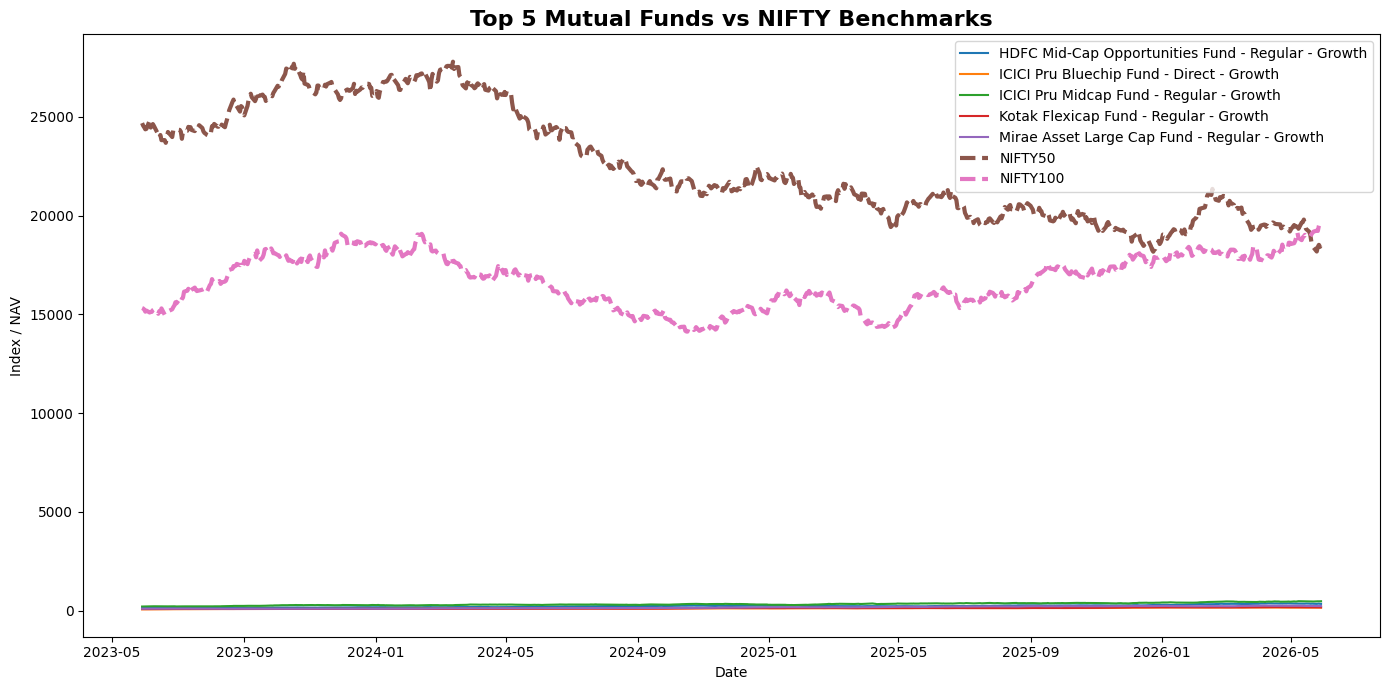

In [98]:
plt.figure(figsize=(14,7))

# Top 5 Funds
for scheme in top5_nav["scheme_name"].unique():

    temp = top5_nav[
        top5_nav["scheme_name"] == scheme
    ]

    plt.plot(
        temp["date"],
        temp["nav"],
        label=scheme
    )

# Benchmarks
for idx in ["NIFTY50","NIFTY100"]:

    temp = benchmark_compare[
        benchmark_compare["index_name"] == idx
    ]

    plt.plot(
        temp["date"],
        temp["close_value"],
        linewidth=3,
        linestyle="--",
        label=idx
    )

plt.title(
    "Top 5 Mutual Funds vs NIFTY Benchmarks",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Index / NAV")

plt.legend()

plt.tight_layout()

plt.show()

In [99]:
tracking_results = []

benchmark_returns = benchmark_compare[
    benchmark_compare["index_name"]=="NIFTY100"
].copy()

benchmark_returns["benchmark_return"] = (
    benchmark_returns["close_value"]
    .pct_change()
)

for code in top5["AMFI Code"]:

    temp = nav[
        nav["amfi_code"] == code
    ]

    merged = temp.merge(
        benchmark_returns[
            ["date","benchmark_return"]
        ],
        on="date"
    )

    merged = merged.dropna()

    tracking_error = (
        (
            merged["daily_return"]
            -
            merged["benchmark_return"]
        ).std()
    ) * np.sqrt(252)

    scheme = fund_master.loc[
        fund_master["amfi_code"]==code,
        "scheme_name"
    ].values[0]

    tracking_results.append([
        scheme,
        tracking_error
    ])

tracking_table = pd.DataFrame(
    tracking_results,
    columns=[
        "Scheme",
        "Tracking Error"
    ]
)

tracking_table

,Scheme,Tracking Error
0,Mirae Asset Large Cap Fund - Regular - Growth,0.187974
1,ICICI Pru Midcap Fund - Regular - Growth,0.232661
2,Kotak Flexicap Fund - Regular - Growth,0.206540
3,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.224976
4,ICICI Pru Bluechip Fund - Direct - Growth,0.187299


In [100]:
tracking_table["Tracking Error"] = (
    tracking_table["Tracking Error"]*100
).round(2)

tracking_table

,Scheme,Tracking Error
0,Mirae Asset Large Cap Fund - Regular - Growth,18.80
1,ICICI Pru Midcap Fund - Regular - Growth,23.27
2,Kotak Flexicap Fund - Regular - Growth,20.65
3,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,22.50
4,ICICI Pru Bluechip Fund - Direct - Growth,18.73


### Business Insight

- The benchmark comparison highlights how the top-performing mutual funds perform relative to the NIFTY 50 and NIFTY 100 indices.
- Funds with consistently higher NAV growth than the benchmark demonstrate stronger long-term performance.
- Tracking Error indicates how closely each fund follows the benchmark index. Lower values suggest closer tracking, while higher values indicate greater deviation.